**<center>Analisis Sewa Sepeda<center>**

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mode

In [9]:
# Open file

bike = pd.read_csv('data_bike_sharing.csv')
bike

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857
...,...,...,...,...,...,...,...,...,...,...,...
12160,2012-01-25,0.75,1,0,1,0.2273,0.24,7,14,243,257
12161,2012-07-06,0.62,1,0,3,0.7424,0.78,0,39,63,102
12162,2012-02-20,0.60,2,1,1,0.2121,0.24,5,0,6,6
12163,2012-03-31,0.77,2,0,2,0.4242,0.42,2,14,55,69


In [10]:
# Identify missing value

bike.info()

<class 'pandas.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      12165 non-null  str    
 1   hum         12165 non-null  float64
 2   weathersit  12165 non-null  int64  
 3   holiday     12165 non-null  int64  
 4   season      12165 non-null  int64  
 5   atemp       12165 non-null  float64
 6   temp        12165 non-null  float64
 7   hr          12165 non-null  int64  
 8   casual      12165 non-null  int64  
 9   registered  12165 non-null  int64  
 10  cnt         12165 non-null  int64  
dtypes: float64(3), int64(7), str(1)
memory usage: 1.0 MB


In [11]:
# Convert dteday from str to date

bike['dteday']=pd.to_datetime(bike['dteday'])

In [12]:
# Re-check data type after converting

bike.info()

<class 'pandas.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      12165 non-null  datetime64[us]
 1   hum         12165 non-null  float64       
 2   weathersit  12165 non-null  int64         
 3   holiday     12165 non-null  int64         
 4   season      12165 non-null  int64         
 5   atemp       12165 non-null  float64       
 6   temp        12165 non-null  float64       
 7   hr          12165 non-null  int64         
 8   casual      12165 non-null  int64         
 9   registered  12165 non-null  int64         
 10  cnt         12165 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(7)
memory usage: 1.0 MB


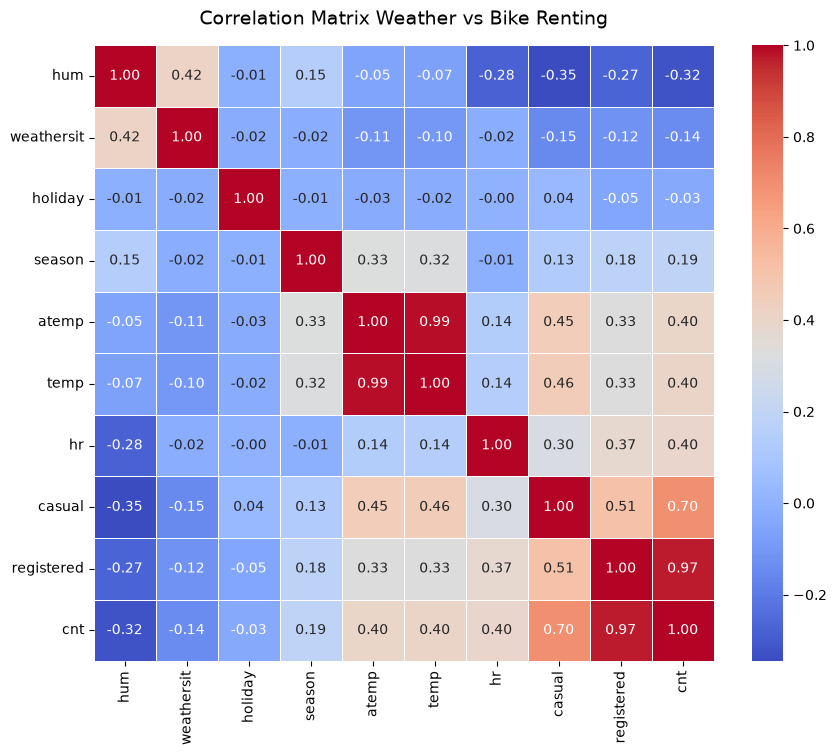

In [13]:
# EDA using heatmap

bike_numeric = bike.select_dtypes(include=['Float64','int64'])
matrix_corr = bike.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_corr,annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix Weather vs Bike Renting", fontsize=14, pad=15)
plt.show()


From the heatmap we know, there's correlation between :
- casual and temp
- casual and hr
- registered and temp
- registered and hr

In [14]:
# Adding Temperature and Humidity

bike['Temperature']=(bike['temp']*47)-8
bike['Humidity']=bike['hum']*100
bike

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt,Temperature,Humidity
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250,8.92,62.0
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18,17.38,64.0
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107,21.14,53.0
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145,8.92,87.0
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857,27.72,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12160,2012-01-25,0.75,1,0,1,0.2273,0.24,7,14,243,257,3.28,75.0
12161,2012-07-06,0.62,1,0,3,0.7424,0.78,0,39,63,102,28.66,62.0
12162,2012-02-20,0.60,2,1,1,0.2121,0.24,5,0,6,6,3.28,60.0
12163,2012-03-31,0.77,2,0,2,0.4242,0.42,2,14,55,69,11.74,77.0


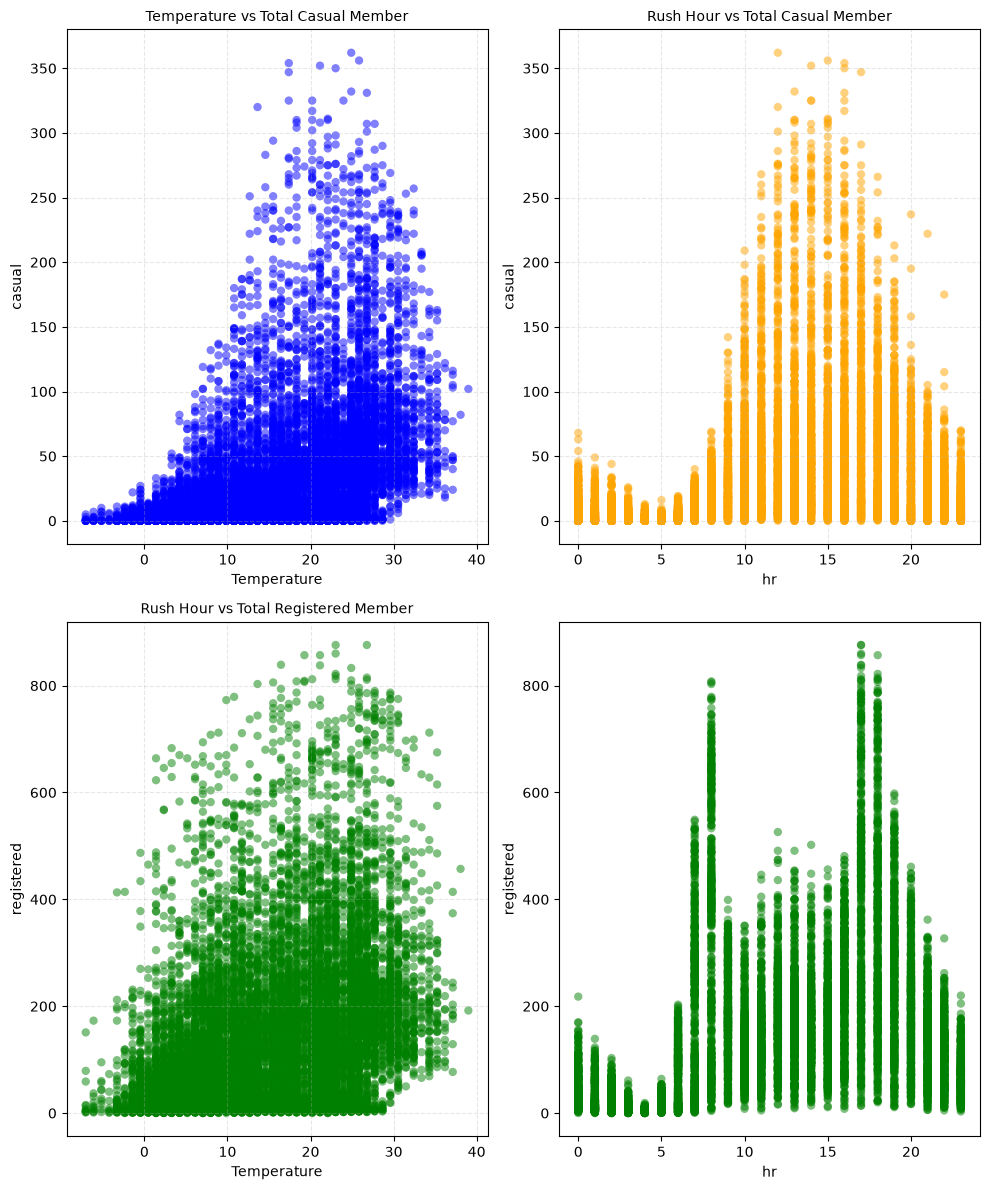

In [15]:
# Scatter Plot

fig, axes = plt.subplots(2, 2, figsize=(10, 12))
sns.scatterplot(ax=axes[0, 0], data=bike, x='Temperature', y='casual', alpha=0.5, color='blue', edgecolor='none')
axes[0, 0].set_title("Temperature vs Total Casual Member", fontsize=10)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

sns.scatterplot(ax=axes[0, 1], data=bike, x='hr', y='casual', alpha=0.5, color='orange', edgecolor='none')
axes[0, 1].set_title("Rush Hour vs Total Casual Member", fontsize=10)
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

sns.scatterplot(ax=axes[1, 0], data=bike, x='Temperature', y='registered', alpha=0.5, color='green', edgecolor='none')
axes[1, 0].set_title("Temperature vs Total Registered Member", fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

sns.scatterplot(ax=axes[1, 1], data=bike, x='hr', y='registered', alpha=0.5, color='green', edgecolor='none')
axes[1, 0].set_title("Rush Hour vs Total Registered Member", fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('matriks_4_scatter_rapat.png', dpi=300, bbox_inches='tight')
plt.show()


Based on scatter plot, we find that :
- Casual members mostly rent the bike in the temperature 20-30 celcius degree
- Mostly casual members will rent the bike at 10:00 a.m 04:00 p.m 
- Similar to casual members, registered member rent the bike in the temperature 20-30 celcius degree
- Registered member will rent the bike around 8:00 a.m - 09:00 a.m and 05:00 p.m until 06:00 p.m

it means the temperature will affect both casual members and registered members to rent the bike, but the time when they rent will be different. It means that we need to provide bikes when the temperature in 20-30 celcius degree.

In [16]:
# Adding Month to dataframe

bike['Month']=bike['dteday'].dt.month_name()
bike_monthly = bike.groupby('Month').agg({
    'casual': 'sum', 
    'registered': 'sum', 
    'cnt': 'sum'
}).reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
bike_monthly['Month'] = pd.Categorical(bike_monthly['Month'], categories=month_order, ordered=True)
df_monthly = bike_monthly.sort_values('Month')
bike

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt,Temperature,Humidity,Month
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250,8.92,62.0,December
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18,17.38,64.0,June
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107,21.14,53.0,June
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145,8.92,87.0,March
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857,27.72,55.0,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12160,2012-01-25,0.75,1,0,1,0.2273,0.24,7,14,243,257,3.28,75.0,January
12161,2012-07-06,0.62,1,0,3,0.7424,0.78,0,39,63,102,28.66,62.0,July
12162,2012-02-20,0.60,2,1,1,0.2121,0.24,5,0,6,6,3.28,60.0,February
12163,2012-03-31,0.77,2,0,2,0.4242,0.42,2,14,55,69,11.74,77.0,March


C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_6316\4137638353.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(df_monthly['Month'], rotation=45, ha='right')
C:\Users\HYPE AMD\AppData\Local\Temp\ipykernel_6316\4137638353.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(df_monthly['Month'], rotation=45, ha='right')


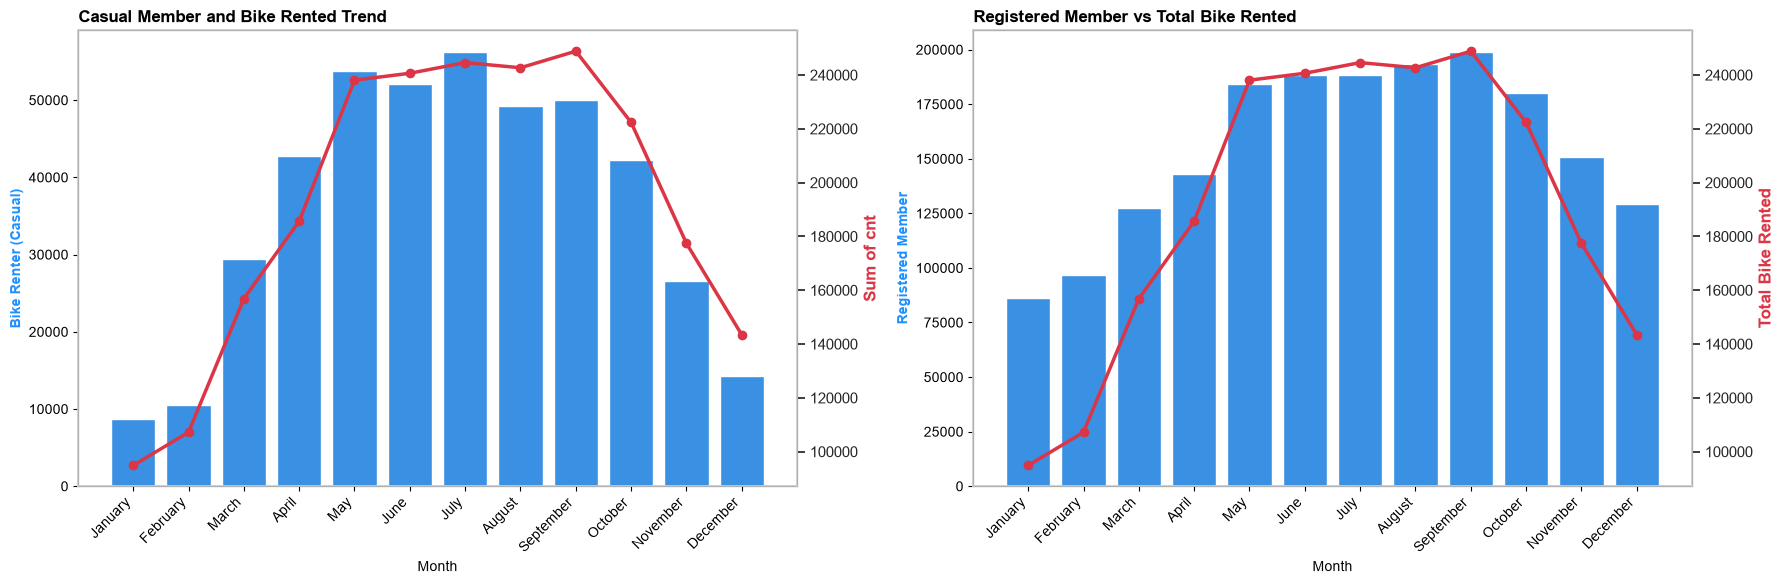

In [17]:
#Bar Chart
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.set_theme(style="whitegrid")


# Bar Chart 1
sns.barplot(data=bike_monthly, x='Month', y='casual', color='#1e90ff', ax=ax1)
ax1.set_ylabel('Bike Renter (Casual)', color='#1e90ff', fontweight='bold')
ax1.set_xticklabels(df_monthly['Month'], rotation=45, ha='right')
ax1.set_title('Casual Member and Bike Rented Trend', fontsize=12, fontweight='bold', loc='left')

# Line Chart 1
ax1_line = ax1.twinx()
ax1_line.plot(bike_monthly.index, df_monthly['cnt'], color='#dc3545', linewidth=2.5, marker='o')
ax1_line.set_ylabel('Sum of cnt', color='#dc3545', fontweight='bold')
ax1_line.grid(False)

# Bar Chart 2
sns.barplot(data=bike_monthly, x='Month', y='registered', color='#1e90ff', ax=ax2)
ax2.set_ylabel('Registered Member', color='#1e90ff', fontweight='bold')
ax2.set_xticklabels(df_monthly['Month'], rotation=45, ha='right')
ax2.set_title('Registered Member vs Total Bike Rented', fontsize=12, fontweight='bold', loc='left')

# Line Chart 2
ax2_line = ax2.twinx()
ax2_line.plot(bike_monthly.index, df_monthly['cnt'], color='#dc3545', linewidth=2.5, marker='o')
ax2_line.set_ylabel('Total Bike Rented', color='#dc3545', fontweight='bold')
ax2_line.grid(False)


plt.tight_layout()
plt.show()



Based on the bar chart, we find that :
- May and July were the peak season for casual members to rent the bike, however the highes bikes rented was September, it means they rented a lot in September
- August and September were the peal season for registered members to rent the bike, however the runner up highest rent is July and September.
Before we go deep dive, let's see the revenue if we use the price $3/hour for casual and $1 for registered/hour

In [31]:
# Revenue Calculation for Casual
casual_revenue = bike['casual']*3
total_casual = casual_revenue.sum()

registered_revenue = bike['registered']*1
total_registered = registered_revenue.sum()

print(f'revenue for casual is: ${total_casual:,.0f} meanwhile revenue for registered is: ${total_registered:,.0f}')

revenue for casual is: $1,307,778 meanwhile revenue for registered is: $1,866,556


We already know the revenue between casual member and registered member. Since both casual and registered have correlation with hr, let's go deep dive to check the peak hour for both

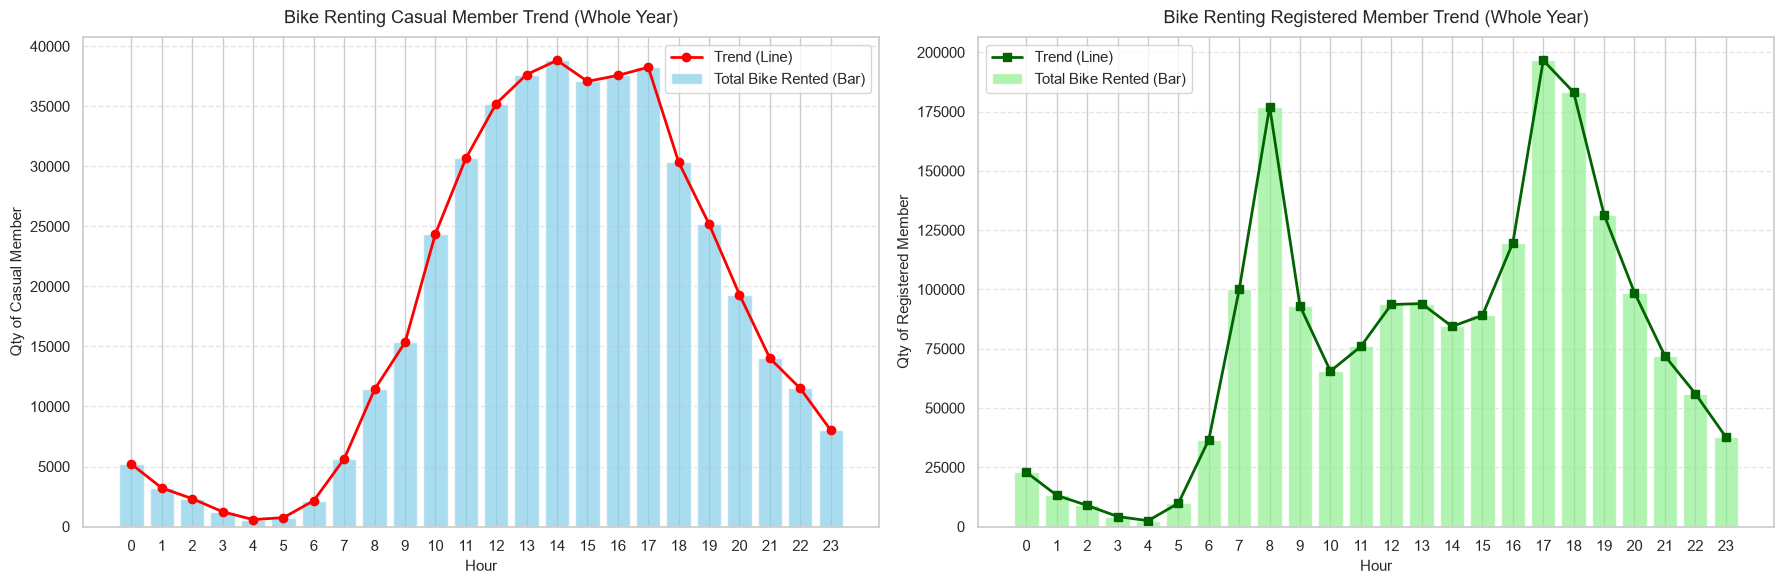

In [42]:
bike_hour_casual = bike.groupby('hr')['casual'].sum()
bike_hour_registered = bike.groupby('hr')['registered'].sum()
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(bike_hour_casual.index, bike_hour_casual, color='skyblue', alpha=0.7, label='Total Bike Rented (Bar)')
axes[0].plot(bike_hour_casual.index, bike_hour_casual, color='red', marker='o', linewidth=2, label='Trend (Line)')
axes[0].set_title('Bike Renting Casual Member Trend (Whole Year)', fontsize=13, pad=10)
axes[0].set_xlabel('Hour', fontsize=11)
axes[0].set_ylabel('Qty of Casual Member', fontsize=11)
axes[0].set_xticks(range(24))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].bar(bike_hour_registered.index, bike_hour_registered, color='lightgreen', alpha=0.7, label='Total Bike Rented (Bar)')
axes[1].plot(bike_hour_registered.index, bike_hour_registered, color='darkgreen', marker='s', linewidth=2, label='Trend (Line)')
axes[1].set_title('Bike Renting Registered Member Trend (Whole Year)', fontsize=13, pad=10)
axes[1].set_xlabel('Hour', fontsize=11)
axes[1].set_ylabel('Qty of Registered Member', fontsize=11)
axes[1].set_xticks(range(24))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()


Based on both bar chart above, we find that:
- casual members mostly rent bikes at 14:00 and 17:00
- registered members mostly rent bikes at 08:00 a.m and 17:00

In [22]:
# Changes season, weathersit, holiday

season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
bike['season'] = bike['season'].map(season_map)

weathersit_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain'}
bike['weathersit'] = bike['weathersit'].map(weathersit_map)

holiday_map = {0:'Working Day', 1:'Holiday'}
bike['holiday']=bike['holiday'].map(holiday_map)